# Computer Vision Project — Architectures that fit, train, and hold on

#### Introduction to Machine Learning | ML Bootcamp

This project has three parts and is worth **100 points**.

| Part | What you build | Points |
|:--|:--|--:|
| 1 | A convolution and a pooling layer **from scratch**, gradient-checked | 30 |
| 2 | A depth experiment: make a deep network fail, then fix it with residuals | 35 |
| 3 | A memory experiment: make an RNN forget, then fix it with an LSTM | 35 |

**You will not finish this in an hour.** Parts 2 and 3 each ask you to build something that
*does not work*, understand exactly why from the evidence, and then repair it.

---

### Compute budget

This notebook is written for a **free Colab T4 (about 2 hours of GPU)**.
Every training run below is sized to finish in a few minutes. Total GPU time if you run
everything once: **roughly 40 minutes**. That leaves you room to make mistakes.

> `Runtime → Change runtime type → T4 GPU`

### Rules

1. Do not import a layer that does the work for you. When a cell says *from scratch*,
   `nn.Conv2d`, `nn.MaxPool2d`, `nn.RNN` and `nn.LSTM` are banned in that cell.
2. Every `assert` in this notebook must pass. They are not decoration — they are the grading.
3. Every question marked **Answer:** needs two or three sentences. One-word answers score zero.


In [2]:
import sys, time, math, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEV)
if DEV.type == "cuda":
    print("gpu   ", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU. Parts 2 and 3 will be painfully slow.")
    print("         Runtime -> Change runtime type -> T4 GPU")


torch 2.11.0+cu128 | device: cuda
gpu    Tesla T4


---
# Part 1 — Convolution and pooling, from scratch  *(30 points)*

You have used `Conv2d` before. In this part you write it yourself, in NumPy, and prove it is
correct against a numerical gradient. After this part you may use PyTorch's layers for the rest
of the notebook — but only after you have earned it.


## 1.1 — Convolution: forward and backward  *(15 pts)*

**Forward.** For every image `n`, every filter `f`, and every output position `(i, j)`:

$$\text{out}[n,f,i,j] \;=\; b[f] \;+\; \sum_{c}\sum_{k}\sum_{l}
x_\text{pad}[n,\,c,\,i\cdot s + k,\,j\cdot s + l]\;\cdot\;w[f,\,c,\,k,\,l]$$

The filter spans **all** input channels — that is the part people get wrong. A `3×3` filter over
a 3-channel input holds `3·3·3 = 27` weights, not 9.

Output size:

$$H_\text{out} = \left\lfloor\frac{H + 2p - HH}{s}\right\rfloor + 1
\qquad
W_\text{out} = \left\lfloor\frac{W + 2p - WW}{s}\right\rfloor + 1$$

**Backward.** Given `dout` (the gradient arriving from above), you need three things:

$$db[f] = \sum_{n,i,j} dout[n,f,i,j]$$

$$dw[f] = \sum_{n,i,j} x_\text{pad}[n,:,\,i s:i s{+}HH,\;j s:j s{+}WW]\cdot dout[n,f,i,j]$$

$$dx_\text{pad}[n,:,\,i s:i s{+}HH,\;j s:j s{+}WW] \mathrel{+}= w[f]\cdot dout[n,f,i,j]$$

That last one is a `+=`, not a `=`. Overlapping windows write to the same input pixels, and every
contribution has to be added. Getting this wrong is the single most common bug here, and the
gradient check below will catch it.

Finally, remember to **strip the padding** off `dx_pad` before returning `dx`.


In [2]:
class MyConv:
    """A 2D convolution layer written by hand. Loops are fine — clarity beats speed here."""

    def __init__(self, stride=1, padding=0):
        self.stride = stride
        self.padding = padding

    def forward(self, x, w, b):
        """
        x : (N, C, H, W)      input
        w : (F, C, HH, WW)    F filters, each spanning all C channels
        b : (F,)              one bias per filter
        returns out : (N, F, H_out, W_out)
        """
        out = None
        stride, pad = self.stride, self.padding

        ############### TODO (1.1a) — forward pass ###############
        N, C, H, W = x.shape
        F_, C_, HH, WW = w.shape
        assert C == C_, "filter channel count must match the input"

        H_out = (H + 2 * pad - HH) // stride + 1
        W_out = (W + 2 * pad - WW) // stride + 1

        x_pad = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))  # hint: np.pad, and do NOT pad N or C
        out = np.zeros((N, F_, H_out, W_out))            # allocate

        for n in range(N):
            for f in range(F_):
                for i in range(H_out):
                    for j in range(W_out):
                        window = x_pad[n, :, i * stride:i * stride + HH, j * stride:j * stride + WW]
                        out[n, f, i, j] = np.sum(window * w[f]) + b[f]
        ############### TODO end ###############

        self.cache = (x, w, b, x_pad)
        return out

    def backward(self, dout):
        """dout : (N, F, H_out, W_out) -> returns dx, dw, db"""
        x, w, b, x_pad = self.cache
        stride, pad = self.stride, self.padding
        dx = dw = db = None

        ############### TODO (1.1b) — backward pass ###############
        N, C, H, W = x.shape
        F_, _, HH, WW = w.shape
        _, _, H_out, W_out = dout.shape

        dw = np.zeros_like(w)
        db = np.zeros_like(b)
        dx_pad = np.zeros_like(x_pad)

        for n in range(N):
            for f in range(F_):
                for i in range(H_out):
                    for j in range(W_out):
                        hs, ws = i * stride, j * stride
                        db[f] += dout[n, f, i, j]
                        dw[f] += x_pad[n, :, hs:hs + HH, ws:ws + WW] * dout[n, f, i, j]
                        dx_pad[n, :, hs:hs + HH, ws:ws + WW] += w[f] * dout[n, f, i, j]

        dx = dx_pad[:, :, pad:pad + H, pad:pad + W]  # remove the padding again
        ############### TODO end ###############

        self.dx, self.dw, self.db = dx, dw, db
        return dx, dw, db


In [3]:
def rel_error(a, b):
    return np.max(np.abs(a - b) / np.maximum(1e-8, np.abs(a) + np.abs(b)))


def numeric_grad(f, x, df, h=1e-5):
    g = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"], op_flags=["readwrite"])
    while not it.finished:
        ix = it.multi_index
        old = x[ix]
        x[ix] = old + h; pos = f(x).copy()
        x[ix] = old - h; neg = f(x).copy()
        x[ix] = old
        g[ix] = np.sum((pos - neg) * df) / (2 * h)
        it.iternext()
    return g


In [4]:
# ---- forward check (DO NOT EDIT) ----
x = np.linspace(-0.1, 0.5, num=2 * 3 * 4 * 4).reshape(2, 3, 4, 4)
w = np.linspace(-0.2, 0.3, num=3 * 3 * 4 * 4).reshape(3, 3, 4, 4)
b = np.linspace(-0.1, 0.2, num=3)

out = MyConv(stride=2, padding=1).forward(x, w, b)
expected = np.array([[[[-0.08759809, -0.10987781], [-0.18387192, -0.2109216]],
                      [[0.21027089, 0.21661097], [0.22847626, 0.23004637]],
                      [[0.50813986, 0.54309974], [0.64082444, 0.67101435]]],
                     [[[-0.98053589, -1.03143541], [-1.19128892, -1.24695841]],
                      [[0.69108355, 0.66880383], [0.59480972, 0.56776003]],
                      [[2.36270298, 2.36904306], [2.38090835, 2.38247847]]]])
err = rel_error(out, expected)
print(f"forward relative error: {err:.3e}")
assert err < 1e-7, "forward pass is wrong"
print("forward OK")


forward relative error: 2.212e-08
forward OK


In [5]:
# ---- backward check against numerical gradients (DO NOT EDIT) ----
rng = np.random.default_rng(1)
x = rng.standard_normal((4, 3, 5, 5))
w = rng.standard_normal((2, 3, 3, 3))
b = rng.standard_normal(2)
dout = rng.standard_normal((4, 2, 5, 5))

conv = MyConv(stride=1, padding=1)
dx_n = numeric_grad(lambda t: conv.forward(t, w, b), x, dout)
dw_n = numeric_grad(lambda t: conv.forward(x, t, b), w, dout)
db_n = numeric_grad(lambda t: conv.forward(x, w, t), b, dout)

conv.forward(x, w, b)
dx, dw, db = conv.backward(dout)

for name, a, n in [("dx", dx, dx_n), ("dw", dw, dw_n), ("db", db, db_n)]:
    e = rel_error(a, n)
    print(f"{name} relative error: {e:.3e}")
    assert e < 1e-7, f"{name} is wrong"
print("backward OK")


dx relative error: 1.792e-09
dw relative error: 3.346e-10
db relative error: 3.494e-12
backward OK


## 1.2 — Max pooling: forward and backward  *(10 pts)*

Pooling has **no parameters**. Nothing here is learned. So what does its backward pass even do?

It **routes**. Out of every window, exactly one input value survived to the output — the maximum.
That one position receives the whole incoming gradient; every other position in the window
receives zero.

> Careful with ties. If two positions in a window hold the same maximum, send the gradient to
> exactly **one** of them, not both. `np.argmax` picks the first; be consistent with your forward
> pass or the gradient check will fail.


In [6]:
class MyMaxPool:
    """Max pooling, written by hand. No parameters — only routing."""

    def __init__(self, size=2, stride=2):
        self.size, self.stride = size, stride

    def forward(self, x):
        """x : (N, C, H, W) -> out : (N, C, H_out, W_out)"""
        out = None
        k, s = self.size, self.stride

        ############### TODO (1.2a) — pooling forward ###############
        N, C, H, W = x.shape
        H_out = (H - k) // s + 1
        W_out = (W - k) // s + 1
        out = np.zeros((N, C, H_out, W_out))

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        hs, ws = i * s, j * s
                        window = x[n, c, hs:hs + k, ws:ws + k]
                        out[n, c, i, j] = np.max(window)
        ############### TODO end ###############

        self.cache = x
        return out

    def backward(self, dout):
        """Send each output gradient back to the one input that produced it."""
        x = self.cache
        k, s = self.size, self.stride
        dx = None

        ############### TODO (1.2b) — pooling backward ###############
        dx = np.zeros_like(x)
        N, C, H_out, W_out = dout.shape

        for n in range(N):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        hs, ws = i * s, j * s
                        window = x[n, c, hs:hs + k, ws:ws + k]
                        # find WHERE the max was, and send the gradient only there
                        pos = np.argmax(window)
                        row, col = pos // k, pos % k
                        dx[n, c, hs + row, ws + col] += dout[n, c, i, j]
        ############### TODO end ###############

        self.dx = dx
        return dx


In [7]:
# ---- pooling checks (DO NOT EDIT) ----
rng = np.random.default_rng(2)
x = rng.standard_normal((3, 2, 6, 6))
pool = MyMaxPool(size=2, stride=2)

out = pool.forward(x)
assert out.shape == (3, 2, 3, 3), f"wrong output shape: {out.shape}"
ref = x.reshape(3, 2, 3, 2, 3, 2).max(axis=(3, 5))
assert rel_error(out, ref) < 1e-12, "pooling forward is wrong"
print("pooling forward OK")

dout = rng.standard_normal(out.shape)
dx_n = numeric_grad(lambda t: pool.forward(t), x, dout)
pool.forward(x)
dx = pool.backward(dout)
e = rel_error(dx, dx_n)
print(f"dx relative error: {e:.3e}")
assert e < 1e-7, "pooling backward is wrong"
assert (dx != 0).sum() == out.size, \
    "exactly one input per window should receive gradient — check your tie handling"
print("pooling backward OK")


pooling forward OK
dx relative error: 3.276e-12
pooling backward OK


## 1.3 — What the kernels actually see  *(5 pts)*

Run four handmade kernels over a real photograph with **your own** `MyConv`, and look at what
comes out. No training, no learning — just nine numbers each.

Build a weight tensor `w` of shape `(4, 3, 3, 3)`: four filters, each spanning all three colour
channels.

| # | filter | what it should do |
|--:|:--|:--|
| 0 | grayscale | weights `0.3 / 0.6 / 0.1` on the R / G / B centre taps, zeros elsewhere |
| 1 | Sobel-x | vertical edges — put the Sobel-x pattern on all three channels, scaled by `1/3` |
| 2 | Sobel-y | horizontal edges |
| 3 | box blur | every tap `1/9`, on all three channels scaled by `1/3` |

$$\text{Sobel}_x=\begin{bmatrix}-1&0&1\\-2&0&2\\-1&0&1\end{bmatrix}
\qquad
\text{Sobel}_y=\begin{bmatrix}-1&-2&-1\\0&0&0\\1&2&1\end{bmatrix}$$


In [10]:
# A sample photo. skimage ships these offline, so this works in Colab with no upload.
try:
    from skimage.data import astronaut, coffee
    imgs = [astronaut(), coffee()]
except Exception:
    from PIL import Image
    imgs = [np.array(Image.open("./Images/Sample/Sharif_1.JPG")),
            np.array(Image.open("./Images/Sample/Sharif_2.jpg"))]

SZ = 256
from PIL import Image as _I
x_img = np.stack([np.array(_I.fromarray(im).resize((SZ, SZ))).transpose(2, 0, 1)
                  for im in imgs]).astype(np.float64)
print("input batch:", x_img.shape)


input batch: (2, 3, 256, 256)


In [11]:

############### TODO (1.3) — build the four filters ###############
w = np.zeros((4, 3, 3, 3))

# filter 0 — grayscale
w[0, 0, 1, 1] = 0.3
w[0, 1, 1, 1] = 0.6
w[0, 2, 1, 1] = 0.1

# filter 1 — Sobel x
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

for c in range(3):
    w[1, c] = sobel_x / 3

# filter 2 — Sobel y
sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

for c in range(3):
    w[2, c] = sobel_y / 3

# filter 3 — box blur
for c in range(3):
    w[3, c] = np.ones((3, 3)) / 27

############### TODO end ###############

b = np.zeros(4)
out = MyConv(stride=1, padding=1).forward(x_img, w, b)
print("output:", out.shape)
assert out.shape == (2, 4, SZ, SZ)


output: (2, 4, 256, 256)


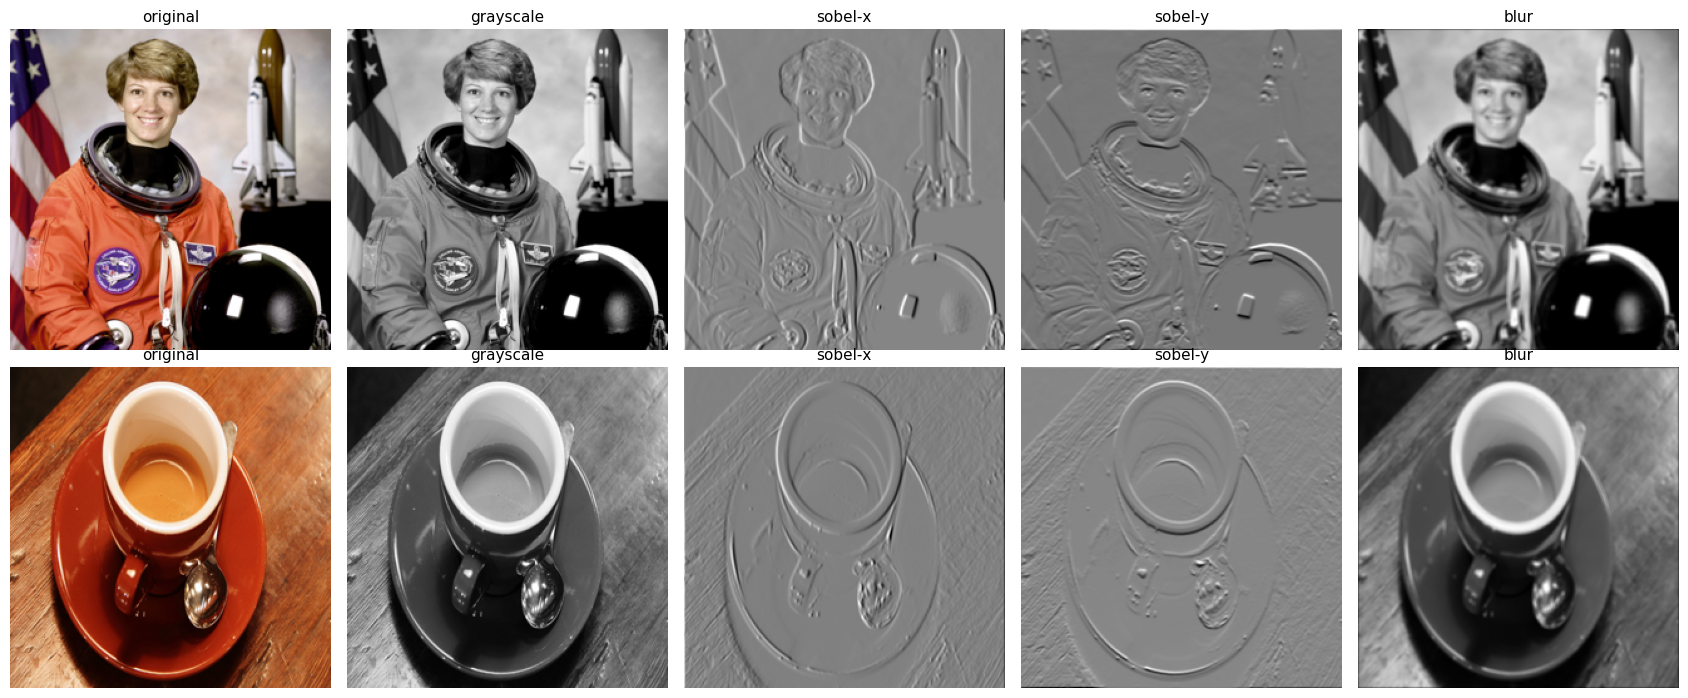

In [12]:
titles = ["original", "grayscale", "sobel-x", "sobel-y", "blur"]
fig, ax = plt.subplots(2, 5, figsize=(17, 7))
for n in range(2):
    ax[n, 0].imshow(x_img[n].transpose(1, 2, 0).astype(np.uint8))
    for f in range(4):
        ax[n, f + 1].imshow(out[n, f], cmap="gray")
    for k in range(5):
        ax[n, k].set_title(titles[k], fontsize=11)
        ax[n, k].axis("off")
plt.tight_layout(); plt.show()


**Answer (1.3).** The Sobel-x output is mostly mid-grey with bright and dark lines. Why mid-grey,
and what does a *dark* line mean as opposed to a bright one?

> _your answer here_   
The Sobel-x output is mostly mid grey because most areas have small horizontal change in brightness.   
that make it producing values almost zero and  dark line shows  a negative response where brightness decreases from left to right or could be implemented reversed and bright line represents a positive response where brightness increases from left to right.

---

# Part 2 — Depth: making a network fail, then fixing it  *(35 points)*

You are going to build a network that gets **worse** when you make it deeper, confirm that the
problem is not overfitting, and then repair it with one wire.

Dataset: **CIFAR-10**, subsampled so every run finishes in a few minutes.


In [3]:
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

tf_train = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(),
                      T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))])
tf_test = T.Compose([T.ToTensor(),
                     T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))])

full_tr = torchvision.datasets.CIFAR10("./data", train=True, download=False, transform=tf_train)
full_te = torchvision.datasets.CIFAR10("./data", train=False, download=False, transform=tf_test)

# a fixed subset keeps every run to a few minutes on a T4
g = torch.Generator().manual_seed(0)
idx = torch.randperm(len(full_tr), generator=g)[:20000]
train_ds = Subset(full_tr, idx.tolist())

train_ld = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2,
                      pin_memory=True, drop_last=True)
test_ld = DataLoader(full_te, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print(f"train {len(train_ds)}  test {len(full_te)}")


train 20000  test 10000


## 2.1 — A configurable network  *(10 pts)*

Build one class that can be either a plain stack or a residual stack, so the **only** thing that
differs between your runs is the shortcut.

The network is three stages. Each stage keeps a fixed channel count, and the first block of a
stage halves the resolution and changes the channel count.

```
stem      : 3×3 conv, 3 -> 32,  BN, ReLU                 32×32
stage 1   : n blocks at  32 channels                     32×32
stage 2   : n blocks at  64 channels, first one stride 2  16×16
stage 3   : n blocks at 128 channels, first one stride 2   8×8
head      : global average pool -> Linear(128, 10)
```

Each **block** is `conv → BN → ReLU → conv → BN`, then `+ shortcut` if `residual=True`, then ReLU.
Depth in weight layers is `2·3·n + 2`. With `n=1` that is 8 layers; with `n=8`, **50** — the range where the original degradation experiments were run.

> **The trap.** In the first block of stages 2 and 3 the shortcut cannot be the identity — the
> resolution halved and the channel count changed. You must project it: a `1×1` convolution with
> the same stride, followed by BatchNorm. If you skip this, `out + x` will raise a shape error.
> That error is the point: it is exactly where a real ResNet needs its projection shortcut.


In [4]:

class Block(nn.Module):
    def __init__(self, c_in, c_out, stride, residual):
        super().__init__()
        self.residual = residual

        ############### TODO (2.1a) — the two convolutions ###############
        self.conv1 = nn.Conv2d(c_in, c_out, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c_out)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c_out)
        ############### TODO end ###############

        # the shortcut
        self.short = nn.Identity()
        if residual and (stride != 1 or c_in != c_out):
            ############### TODO (2.1b) — projection shortcut ###############
            # a 1x1 conv with the SAME stride, then BatchNorm
            self.short = nn.Sequential(
                nn.Conv2d(c_in, c_out, 1, stride=stride, bias=False),
                nn.BatchNorm2d(c_out)
            )
            ############### TODO end ###############

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        ############### TODO (2.1c) — add the shortcut, only if residual ###############
        if self.residual:
            out = out + self.short(x)
        ############### TODO end ###############
        return F.relu(out)


class Net(nn.Module):
    def __init__(self, n=1, residual=False, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 32, 3, 1, 1, bias=False),
                                  nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        layers, c_in = [], 32
        for c_out, stride in [(32, 1), (64, 2), (128, 2)]:
            for k in range(n):
                layers.append(Block(c_in, c_out, stride if k == 0 else 1, residual))
                c_in = c_out
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.body(self.stem(x))
        return self.head(F.adaptive_avg_pool2d(x, 1).flatten(1))


def depth_of(n):
    return 2 * 3 * n + 2


In [5]:
# ---- shape checks (DO NOT EDIT) ----
for n in (1, 8):
    for res in (False, True):
        m = Net(n=n, residual=res)
        y = m(torch.randn(2, 3, 32, 32))
        assert y.shape == (2, 10), f"bad output shape for n={n}, residual={res}"
print("shapes OK")

m = Net(n=8, residual=True)
proj = [b for b in m.body if not isinstance(b.short, nn.Identity)]
assert len(proj) == 2, (f"expected exactly 2 projection shortcuts (one per downsampling stage), "
                        f"found {len(proj)} — re-read the trap above")
print(f"depth n=1 -> {depth_of(1)} layers,  n=8 -> {depth_of(8)} layers")
print(f"params n=8 residual: {sum(p.numel() for p in m.parameters()):,}")
print("projection shortcuts OK")


shapes OK
depth n=1 -> 8 layers,  n=8 -> 50 layers
params n=8 residual: 3,024,426
projection shortcuts OK


## 2.2 — Run the experiment  *(10 pts)*

Four runs: `n ∈ {1, 8}` × `residual ∈ {False, True}` — that is 8 layers against 50.
Everything else is identical.

Record the **training** loss every epoch, not just the test accuracy. Degradation is a statement
about training error — if you only look at test accuracy you cannot tell it apart from overfitting.


In [6]:
def train(model, epochs=12, lr=0.1, tag="", log_grads=False):
    model = model.to(DEV)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    lossf = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "test_acc": []}
    t0 = time.time()

    for ep in range(epochs):
        model.train(); tot = nb = 0
        for xb, yb in train_ld:
            xb, yb = xb.to(DEV, non_blocking=True), yb.to(DEV, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = lossf(model(xb), yb)
            loss.backward()
            opt.step()
            tot += loss.item(); nb += 1
        sched.step()
        hist["train_loss"].append(tot / nb)

        model.eval(); ok = tot_n = 0
        with torch.no_grad():
            for xb, yb in test_ld:
                xb, yb = xb.to(DEV), yb.to(DEV)
                ok += (model(xb).argmax(1) == yb).sum().item(); tot_n += yb.numel()
        hist["test_acc"].append(ok / tot_n)
        print(f"  [{tag}] epoch {ep+1:>2}/{epochs}  train_loss {hist['train_loss'][-1]:.4f}"
              f"  test_acc {hist['test_acc'][-1]*100:5.2f}%")

    print(f"  [{tag}] done in {time.time()-t0:.0f}s")
    return hist


In [7]:
# The two depth-50 runs are the slow ones: roughly 6 minutes each on a T4.
# Four runs, so budget about 18 minutes. Go make tea.
results = {}
for n in (1, 8):
    for res in (False, True):
        name = f"depth{depth_of(n)}-{'res' if res else 'plain'}"
        print(f"\n=== {name} ===")
        torch.manual_seed(SEED)
        results[name] = train(Net(n=n, residual=res), epochs=10, tag=name)



=== depth8-plain ===
  [depth8-plain] epoch  1/10  train_loss 1.7729  test_acc 35.36%
  [depth8-plain] epoch  2/10  train_loss 1.4465  test_acc 40.48%
  [depth8-plain] epoch  3/10  train_loss 1.2576  test_acc 53.69%
  [depth8-plain] epoch  4/10  train_loss 1.1121  test_acc 55.01%
  [depth8-plain] epoch  5/10  train_loss 0.9907  test_acc 60.18%
  [depth8-plain] epoch  6/10  train_loss 0.9033  test_acc 63.36%
  [depth8-plain] epoch  7/10  train_loss 0.8249  test_acc 69.80%
  [depth8-plain] epoch  8/10  train_loss 0.7484  test_acc 71.88%
  [depth8-plain] epoch  9/10  train_loss 0.6953  test_acc 73.13%
  [depth8-plain] epoch 10/10  train_loss 0.6545  test_acc 74.63%
  [depth8-plain] done in 102s

=== depth8-res ===
  [depth8-res] epoch  1/10  train_loss 1.7560  test_acc 40.45%
  [depth8-res] epoch  2/10  train_loss 1.4353  test_acc 44.02%
  [depth8-res] epoch  3/10  train_loss 1.2202  test_acc 56.44%
  [depth8-res] epoch  4/10  train_loss 1.0877  test_acc 56.33%
  [depth8-res] epoch  5/10

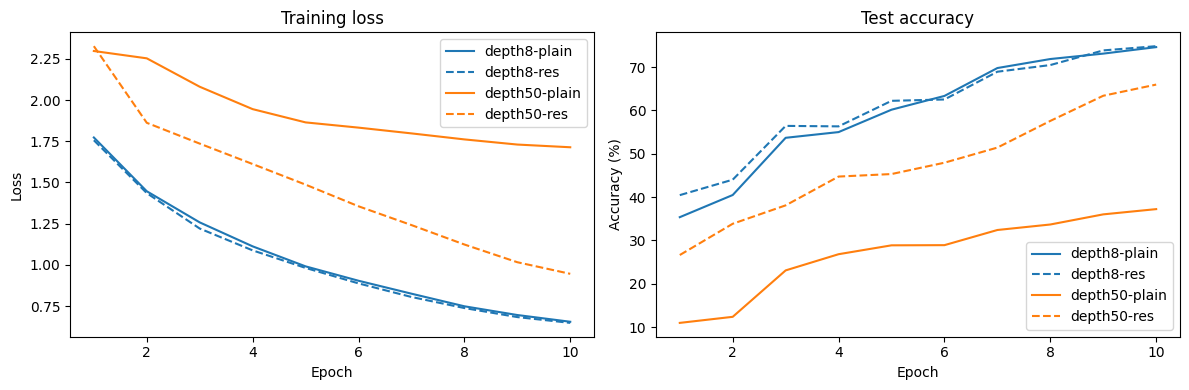

In [8]:

############### TODO (2.2) — plot the four runs ###############
# Left panel : training loss per epoch, all four curves.
# Right panel: test accuracy per epoch, all four curves.
# Use one colour per depth and one line style per residual/plain, so the comparison is readable.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {8: "tab:blue", 50: "tab:orange"}
styles = {"plain": "-", "res": "--"}

for depth in (8, 50):
    for kind in ("plain", "res"):
        name = f"depth{depth}-{kind}"
        history = results[name]
        epochs = range(1, len(history["train_loss"]) + 1)

        axes[0].plot(
            epochs, history["train_loss"],
            color=colors[depth],
            linestyle=styles[kind],
            label=name
        )

        axes[1].plot(
            epochs, [acc * 100 for acc in history["test_acc"]],
            color=colors[depth],
            linestyle=styles[kind],
            label=name
        )

axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("Test accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

############### TODO end ###############


In [9]:
print(f"{'run':<22}{'final train loss':>18}{'final test acc':>17}")
for k, h in results.items():
    print(f"{k:<22}{h['train_loss'][-1]:>18.4f}{h['test_acc'][-1]*100:>16.2f}%")


run                     final train loss   final test acc
depth8-plain                      0.6545           74.63%
depth8-res                        0.6476           74.85%
depth50-plain                     1.7136           37.22%
depth50-res                       0.9454           65.98%


**Answer (2.2a).** Compare `depth50-plain` against `depth8-plain` on **training loss** — not test
accuracy. Report both final numbers. Which is lower?

This is a real experiment, so report what you measured, not what you expected.

- If the deeper plain network is **worse**, you have reproduced the degradation result: more
  capacity, worse fit.
- If it is **not** worse, say so, and then explain what is protecting your network that a plain
  1990s stack did not have. Look at what sits between every convolution and its ReLU, and at how
  deep the original experiments had to go before the effect showed up.

Either way: explain why **training** loss, and not test accuracy, is the only number that can tell
degradation apart from overfitting.

> _your answer here_   
the depth8 plain network has a final training loss of 0.6686 while depth50 plain has a much higher loss 1.7408. this shows that the deeper network performed worse even though it has more layers and capacity to learn.
this is an example of the vanishing gradient problem, where adding more layers makes the network harder to train instead of improving it.  
we compare training loss instead of test accuracy because vanishing gradient problem means the network cannot fit the training data properly. with overfitting training loss can be low while test accuracy is poor.


**Answer (2.2b).** Now compare `depth50-res` against `depth50-plain`. Nearly the same parameter
count, exactly the same capacity — the residual version can express nothing the plain one cannot.
Compare their loss curves epoch by epoch, not just the final number. What did the shortcut change?

> _your answer here_   
at the first epoch depth50 res has a little higher training loss than depth50 plain (2.3352 vs 2.3019) but from the second epoch the residual network starts improving much faster and keeps a lower loss for the rest of the training.   
at epoch 10, depth50 res reaches 0.9928 while depth50 plain is still at 1.7408.   
the shortcut connections help gradients flow through the deeper network and make training easier and the problem of vanishing. this shows that the problem with the plain network is not just its depth but also how difficult it is to optimize without residual connections.

## 2.3 — Look at the gradient itself  *(15 pts)*

You have the symptom. Now get the evidence.

For a **single batch at initialisation** — do not train first — measure the gradient arriving at
the output of every block, and plot it against block index for both networks.

Two details that decide whether your measurement means anything:

- **Normalise by the number of elements.** Early blocks carry much larger feature maps than late
  ones, so a raw gradient *norm* is larger there simply because more numbers are being summed.
  Divide by `sqrt(numel)` and you are comparing a per-element magnitude, with the feature-map size
  divided out. Skip this and you will measure the shape of the network, not its gradient.
- **Log scale on the y axis.** The differences here span orders of magnitude.

Hint: run a forward pass while keeping a handle on every block's output, call `.retain_grad()` on
each of them, run `backward()` on the loss, then read `.grad`.


In [10]:

def block_grad_norms(model, xb, yb):
    """Per-element RMS gradient at the output of every block, ordered input -> output."""
    model = model.to(DEV).train()
    norms = []

    ############### TODO (2.3) — instrument the forward pass ###############
    # 1. push xb through model.stem
    # 2. loop over model.body, keeping each block's output; call retain_grad() on it
    # 3. finish with the head, compute the cross-entropy loss against yb
    # 4. loss.backward()
    # 5. for each kept activation a, append  (a.grad.norm() / a.grad.numel() ** 0.5).item()

    model.zero_grad(set_to_none=True)

    x = model.stem(xb)
    outputs = []

    for block in model.body:
        x = block(x)
        x.retain_grad()
        outputs.append(x)

    x = F.adaptive_avg_pool2d(x, 1).flatten(1)
    x = model.head(x)

    loss = F.cross_entropy(x, yb)
    loss.backward()

    for a in outputs:
        grad = a.grad
        norm = grad.norm() / (grad.numel() ** 0.5)
        norms.append(norm.item())

    ############### TODO end ###############

    return norms


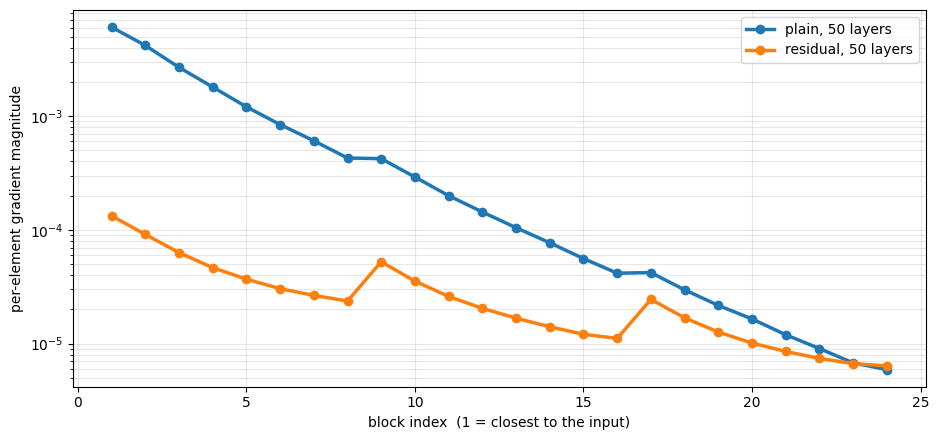

plain    spread across depth: 1.02e+03   (3.0 orders of magnitude)
residual spread across depth: 2.08e+01   (1.3 orders of magnitude)


In [11]:
xb, yb = next(iter(train_ld))
xb, yb = xb.to(DEV), yb.to(DEV)

torch.manual_seed(SEED); g_plain = block_grad_norms(Net(n=8, residual=False), xb, yb)
torch.manual_seed(SEED); g_res = block_grad_norms(Net(n=8, residual=True), xb, yb)

NB = 24
assert len(g_plain) == NB and len(g_res) == NB, "expected one number per block (3 stages x 8)"

plt.figure(figsize=(9.5, 4.5))
plt.semilogy(range(1, NB + 1), g_plain, "o-", lw=2.5, label="plain, 50 layers")
plt.semilogy(range(1, NB + 1), g_res, "o-", lw=2.5, label="residual, 50 layers")
plt.xlabel("block index  (1 = closest to the input)")
plt.ylabel("per-element gradient magnitude")
plt.grid(alpha=.3, which="both"); plt.legend(); plt.tight_layout(); plt.show()

sp = max(g_plain) / min(g_plain)
sr = max(g_res) / min(g_res)
print(f"plain    spread across depth: {sp:.2e}   ({math.log10(sp):.1f} orders of magnitude)")
print(f"residual spread across depth: {sr:.2e}   ({math.log10(sr):.1f} orders of magnitude)")


**Answer (2.3a).** Describe both curves. Over the whole depth, by how many **orders of magnitude**
does the per-element gradient change in each network? Which of the two is better conditioned?

> _your answer here_   
the plain networks gradient changes by about 3 orders of magnitude while the residual network changes by around 1.3 orders of magnitude.
the plain network has a much larger gradient near the input which decreases a lot towards the final blocks. the residual network has a more stable gradient throughout the layers so it is better conditioned.

**Answer (2.3b).** Now the part worth thinking about.

In the lecture, a plain deep stack was described as making gradients **vanish** on the way back.
With BatchNorm in every block — which is what you just built — you will most likely measure the
*opposite*: in the plain network the gradient **grows** towards the input, by a large factor, while
the residual network stays within about one order of magnitude end to end.

These are not two different diseases. Name the single underlying problem that both symptoms are
evidence of, and say precisely what the shortcut does about it. Your answer should not contain the
word "vanishing" as an explanation, because here it is not what happened.

> _your answer here_   
the main problem is unstable gradient propagation through many layers. The gradients can become either too large or too small as they pass through the network.   
in our experiment the plain networks gradients grow a lot when moving backward towards the input. the residual network uses shortcut connections that create a direct path for gradients to flow backward without having to pass through every convolution. this helps keep the gradients more stable and makes the deeper network easier to train.
---


# Part 3 — Time: making a network forget, then fixing it  *(35 points)*

Part 2 was about distance in **depth**. This part is about distance in **time**.

### The task

Each sample is a sequence of `T` MNIST frames.

```
frame 0        the CUE     digit  d0
frames 1..T-2  distractors        random digits, irrelevant
frame T-1      the QUERY   digit  dq

label = (d0 + dq) mod 10
```

The answer needs **both** ends of the sequence. A model that only looks at the last frame is stuck
at 10% — chance. To do better it has to carry `d0` across `T-1` steps and still have it at the end.

At `T=4` that is easy. At `T=24` it is not, and *why* it is not is the whole point of this part.


In [12]:
mnist_tr = torchvision.datasets.MNIST("./data", train=True, download=True,
                                      transform=T.ToTensor())
mnist_te = torchvision.datasets.MNIST("./data", train=False, download=True,
                                      transform=T.ToTensor())

def _pack(ds, n):
    xs = torch.stack([ds[i][0] for i in range(n)])          # (n,1,28,28)
    ys = torch.tensor([ds[i][1] for i in range(n)])
    return xs, ys

TR_X, TR_Y = _pack(mnist_tr, 20000)
TE_X, TE_Y = _pack(mnist_te, 4000)
print("pool:", TR_X.shape, TE_X.shape)


class SeqTask(torch.utils.data.Dataset):
    """Build (T, 1, 28, 28) sequences on the fly. Label = (first + last) mod 10."""

    def __init__(self, X, Y, T_len, size, seed=0):
        self.X, self.Y, self.T, self.size = X, Y, T_len, size
        self.g = np.random.default_rng(seed)
        self.idx = self.g.integers(0, len(X), size=(size, T_len))

    def __len__(self):
        return self.size

    def __getitem__(self, i):
        ids = self.idx[i]
        seq = self.X[ids]                                   # (T,1,28,28)
        label = (self.Y[ids[0]].item() + self.Y[ids[-1]].item()) % 10
        return seq, label


def seq_loaders(T_len, bs=64, n_tr=12000, n_te=2000):
    tr = SeqTask(TR_X, TR_Y, T_len, n_tr, seed=1)
    te = SeqTask(TE_X, TE_Y, T_len, n_te, seed=2)
    return (DataLoader(tr, batch_size=bs, shuffle=True, num_workers=2, drop_last=True),
            DataLoader(te, batch_size=256, shuffle=False, num_workers=2))


# sanity: a model that ignores frame 0 cannot beat chance
_tr, _ = seq_loaders(8)
_x, _y = next(iter(_tr))
print("batch:", _x.shape, "labels:", _y[:8].tolist())
print("label histogram is roughly uniform:", np.bincount(_y.numpy(), minlength=10))


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]


pool: torch.Size([20000, 1, 28, 28]) torch.Size([4000, 1, 28, 28])
batch: torch.Size([64, 8, 1, 28, 28]) labels: [3, 8, 4, 3, 6, 6, 6, 7]
label histogram is roughly uniform: [ 4  3  9 12  5  5  6  7  6  7]


## 3.1 — A recurrent cell, by hand  *(10 pts)*

`nn.RNN` and `nn.LSTM` are banned in this part. Write the recurrence yourself so you can see
exactly what gets multiplied.

**The plain RNN cell:**

$$h_t = \tanh\big(W_{xh}\,x_t + W_{hh}\,h_{t-1} + b\big)$$

The same `W_hh` is applied at **every** step. That is what makes the sequence trainable at any
length — and it is also what puts `W_hh` to the power of `T` in the backward pass.


In [13]:

class Encoder(nn.Module):
    """A small CNN applied to each frame independently. Shared across time."""

    def __init__(self, out_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),   # 14x14
            nn.Conv2d(16, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),  # 7x7
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32, out_dim), nn.ReLU())

    def forward(self, x):                      # (B,1,28,28) -> (B,out_dim)
        return self.net(x)


class MyRNNCell(nn.Module):
    def __init__(self, in_dim, hid):
        super().__init__()
        ############### TODO (3.1a) — parameters ###############
        self.Wx = nn.Linear(in_dim, hid)
        self.Wh = nn.Linear(hid, hid, bias=False)
        ############### TODO end ###############
        self.hid = hid

    def forward(self, x, h):
        ############### TODO (3.1b) — one step ###############
        return torch.tanh(self.Wx(x) + self.Wh(h))
        ############### TODO end ###############


In [14]:

class SeqModel(nn.Module):
    """Encoder per frame -> recurrent cell over time -> classifier on the LAST state."""

    def __init__(self, cell_type="rnn", hid=128, enc_dim=64):
        super().__init__()
        self.enc = Encoder(enc_dim)
        self.cell_type = cell_type
        self.hid = hid
        self.cell = MyRNNCell(enc_dim, hid) if cell_type == "rnn" else MyLSTMCell(enc_dim, hid)
        self.head = nn.Linear(hid, 10)

    def forward(self, seq, keep_states=False):
        """seq : (B, T, 1, 28, 28)"""
        B, Tn = seq.shape[0], seq.shape[1]
        feats = self.enc(seq.reshape(B * Tn, *seq.shape[2:])).reshape(B, Tn, -1)

        h = torch.zeros(B, self.hid, device=seq.device)
        c = torch.zeros(B, self.hid, device=seq.device)
        states = []

        for t in range(Tn):
            ############### TODO (3.1c) — run one step ###############
            # rnn : h = self.cell(feats[:, t], h)
            # lstm: h, c = self.cell(feats[:, t], h, c)
            # DO NOT call .detach() on h or c. If you do, no gradient reaches earlier
            # timesteps and the whole experiment is meaningless.
            if self.cell_type == "rnn":
                h = self.cell(feats[:, t], h)
            else:
                h, c = self.cell(feats[:, t], h, c)
            ############### TODO end ###############
            if keep_states:
                h.retain_grad()
                states.append(h)

        out = self.head(h)
        return (out, states) if keep_states else out


## 3.2 — Watch it forget  *(10 pts)*

Train the plain RNN at `T=4` and at `T=24`. Same model, same everything — only the distance
between the cue and the question changes.


In [15]:
def train_seq(model, T_len, epochs=6, lr=2e-3, tag=""):
    tr, te = seq_loaders(T_len)
    model = model.to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    hist = {"train_loss": [], "test_acc": []}
    t0 = time.time()

    for ep in range(epochs):
        model.train(); tot = nb = 0
        for xb, yb in tr:
            xb, yb = xb.to(DEV, non_blocking=True), yb.to(DEV, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = lossf(model(xb), yb)
            loss.backward()
            opt.step()
            tot += loss.item(); nb += 1
        hist["train_loss"].append(tot / nb)

        model.eval(); ok = n = 0
        with torch.no_grad():
            for xb, yb in te:
                xb, yb = xb.to(DEV), yb.to(DEV)
                ok += (model(xb).argmax(1) == yb).sum().item(); n += yb.numel()
        hist["test_acc"].append(ok / n)
        print(f"  [{tag}] epoch {ep+1}/{epochs}  loss {hist['train_loss'][-1]:.4f}"
              f"  acc {hist['test_acc'][-1]*100:5.2f}%")

    print(f"  [{tag}] done in {time.time()-t0:.0f}s")
    return hist


In [16]:
# roughly 2 minutes at T=4 and 5 minutes at T=24 on a T4
seq_results = {}
for T_len in (4, 24):
    name = f"rnn-T{T_len}"
    print(f"\n=== {name} ===")
    torch.manual_seed(SEED)
    seq_results[name] = train_seq(SeqModel("rnn"), T_len, epochs=6, tag=name)


=== rnn-T4 ===
  [rnn-T4] epoch 1/6  loss 2.3063  acc 10.40%
  [rnn-T4] epoch 2/6  loss 2.3029  acc  9.40%
  [rnn-T4] epoch 3/6  loss 2.3024  acc 10.35%
  [rnn-T4] epoch 4/6  loss 2.3020  acc 11.25%
  [rnn-T4] epoch 5/6  loss 2.3011  acc 11.20%
  [rnn-T4] epoch 6/6  loss 2.3004  acc 10.30%
  [rnn-T4] done in 11s

=== rnn-T24 ===
  [rnn-T24] epoch 1/6  loss 2.3063  acc 10.45%
  [rnn-T24] epoch 2/6  loss 2.3047  acc  9.30%
  [rnn-T24] epoch 3/6  loss 2.3036  acc  9.75%
  [rnn-T24] epoch 4/6  loss 2.3031  acc  9.60%
  [rnn-T24] epoch 5/6  loss 2.3024  acc 10.20%
  [rnn-T24] epoch 6/6  loss 2.3029  acc  9.95%
  [rnn-T24] done in 28s


**Answer (3.2).** Report both accuracies. Chance is 10%. Did the `T=24` run learn anything at all?
State clearly what changed between the two runs and what did **not** change.

> _your answer here_   
the RNN with T=4 reached 10.30 accuracy while T=24 reached 9.95. both results are around the 10% chance level which means neither model really learned the task.   
the T=24 model didnt learn anything useful and the longer sequence makes it harder for the RNN to remember the first frame.   
the only thing that changed between the two runs was the sequence length from 4 to 24. the model training settings and number of epochs stayed the same.

## 3.3 — Where the signal dies  *(5 pts)*

Accuracy tells you it failed. This tells you *where*.

Using `keep_states=True`, take one batch, run a backward pass, and record
`states[t].grad.norm()` for every timestep `t`. Plot it against `t` on a log scale.


In [17]:

def timestep_grad_norms(model, T_len, batch=64):
    tr, _ = seq_loaders(T_len, bs=batch)
    xb, yb = next(iter(tr))
    xb, yb = xb.to(DEV), yb.to(DEV)
    model = model.to(DEV).train()

    ############### TODO (3.3) — one forward, one backward, read the norms ###############
    # out, states = model(xb, keep_states=True)
    # loss = F.cross_entropy(out, yb); loss.backward()
    # return [s.grad.norm().item() for s in states]

    model.zero_grad(set_to_none=True)

    out, states = model(xb, keep_states=True)
    loss = F.cross_entropy(out, yb)
    loss.backward()

    return [s.grad.norm().item() for s in states]

    ############### TODO end ###############


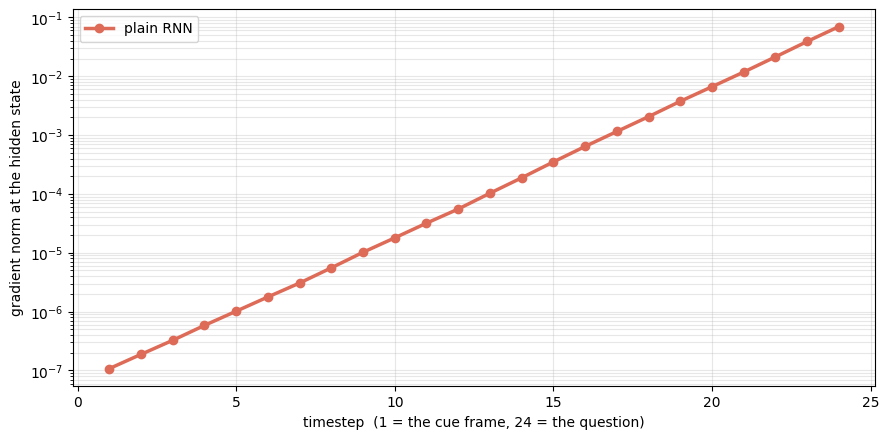

gradient at t=1 is 6.50e+05 times smaller than at t=24


In [18]:
torch.manual_seed(SEED)
gn_rnn = timestep_grad_norms(SeqModel("rnn"), 24)
assert len(gn_rnn) == 24

plt.figure(figsize=(9, 4.5))
plt.semilogy(range(1, 25), gn_rnn, "o-", lw=2.5, color="#DE6B58", label="plain RNN")
plt.xlabel("timestep  (1 = the cue frame, 24 = the question)")
plt.ylabel("gradient norm at the hidden state")
plt.grid(alpha=.3, which="both"); plt.legend(); plt.tight_layout(); plt.show()

print(f"gradient at t=1 is {gn_rnn[-1]/max(gn_rnn[0],1e-30):.2e} times smaller than at t=24")


**Answer (3.3).** The gradient at the cue frame is many orders of magnitude smaller than at the
question frame. Explain this using the recurrence you wrote in 3.1 — which quantity gets raised
to a power, and why does that make the cue unlearnable rather than merely hard?

> _your answer here_     
the graph shows that the gradient becomes much smaller as we move backward from the last timestep to the first one. it drops from around \(10^{-1}\) to \(10^{-7}\) which is about 6 orders of magnitude.
this is the vanishing gradient problem. the gradient almost disappears before reaching the first frame so the RNN has difficulty learning information from it. this also explains why the RNN with T=24 performed poorly in Part 3.2 since it needs to remember information from the first frame across 24 timesteps.


## 3.4 — Fix it: an LSTM cell, by hand  *(10 pts)*

Now write the LSTM cell yourself. Same interface, one extra state.

$$
\begin{aligned}
f_t &= \sigma\!\left(W_f\,[x_t, h_{t-1}]\right) &\quad&\text{forget: what to erase} \\
i_t &= \sigma\!\left(W_i\,[x_t, h_{t-1}]\right) &&\text{input: how much to write} \\
g_t &= \tanh\!\left(W_g\,[x_t, h_{t-1}]\right) &&\text{candidate: what to write} \\
o_t &= \sigma\!\left(W_o\,[x_t, h_{t-1}]\right) &&\text{output: what to read out} \\[4pt]
c_t &= f_t \odot c_{t-1} \;+\; i_t \odot g_t &&\textbf{the cell state} \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

Two things to notice while you write it.

1. `c_t` is built by **adding** to `c_{t-1}`, scaled by a gate that the network can set near 1.
   Compare that to the RNN, where `h` is rebuilt from scratch every step.
2. **Initialise the forget-gate bias to `+1`.** Then `σ(1) ≈ 0.73` and the cell starts in
   *remember* mode and learns what to drop. Start it at 0 and half the memory is thrown away at
   every step before training has learned anything.


In [19]:

class MyLSTMCell(nn.Module):
    def __init__(self, in_dim, hid):
        super().__init__()
        self.hid = hid

        ############### TODO (3.4a) — parameters ###############
        # One Linear from (in_dim + hid) to 4*hid is the clean way: compute all four
        # pre-activations in a single matmul and split the result.
        self.gates = nn.Linear(in_dim + hid, 4 * hid)
        ############### TODO end ###############

        ############### TODO (3.4b) — forget-gate bias init ###############
        # set the forget-gate slice of self.gates.bias to +1.0, in-place, under no_grad

        with torch.no_grad():
            self.gates.bias.zero_()
            self.gates.bias[:hid].fill_(1.0)

        ############### TODO end ###############

    def forward(self, x, h, c):
        ############### TODO (3.4c) — one step ###############
        # concat x and h, one matmul, chunk into 4, apply sigmoid/tanh, update c then h

        combined = torch.cat((x, h), dim=1)

        f, i, g, o = self.gates(combined).chunk(4, dim=1)

        f = torch.sigmoid(f)
        i = torch.sigmoid(i)
        g = torch.tanh(g)
        o = torch.sigmoid(o)

        c = f * c + i * g
        h = o * torch.tanh(c)

        return h, c
        ############### TODO end ###############


In [20]:
# ---- LSTM cell checks (DO NOT EDIT) ----
cell = MyLSTMCell(8, 16)
h0, c0 = torch.zeros(5, 16), torch.zeros(5, 16)
h1, c1 = cell(torch.randn(5, 8), h0, c0)
assert h1.shape == (5, 16) and c1.shape == (5, 16), "wrong output shapes"

n_par = sum(p.numel() for p in cell.parameters())
assert n_par == 4 * 16 * (8 + 16) + 4 * 16, f"expected {4*16*(8+16)+4*16} parameters, got {n_par}"

b = cell.gates.bias.detach()
assert (b.abs() > 0.5).sum() >= 16, "the forget-gate bias does not look initialised to +1"

# with a zero input and zero state, c must stay put: nothing has been written yet
h, c = cell(torch.zeros(5, 8), h0, c0)
assert c.abs().max() < 1e-6, "c changed when nothing was written — check your update rule"
print(f"LSTM cell OK  ({n_par:,} parameters)")


LSTM cell OK  (1,600 parameters)


In [21]:
# roughly 3 and 7 minutes on a T4
for T_len in (4, 24):
    name = f"lstm-T{T_len}"
    print(f"\n=== {name} ===")
    torch.manual_seed(SEED)
    seq_results[name] = train_seq(SeqModel("lstm"), T_len, epochs=6, tag=name)



=== lstm-T4 ===
  [lstm-T4] epoch 1/6  loss 2.3041  acc  9.80%
  [lstm-T4] epoch 2/6  loss 2.3031  acc 10.20%
  [lstm-T4] epoch 3/6  loss 2.3027  acc  9.60%
  [lstm-T4] epoch 4/6  loss 2.3027  acc  9.60%
  [lstm-T4] epoch 5/6  loss 2.3026  acc  9.15%
  [lstm-T4] epoch 6/6  loss 2.3026  acc  9.25%
  [lstm-T4] done in 12s

=== lstm-T24 ===
  [lstm-T24] epoch 1/6  loss 2.3045  acc 10.35%
  [lstm-T24] epoch 2/6  loss 2.3031  acc  9.45%
  [lstm-T24] epoch 3/6  loss 2.3031  acc 10.25%
  [lstm-T24] epoch 4/6  loss 2.3031  acc 10.40%
  [lstm-T24] epoch 5/6  loss 2.3029  acc  9.95%
  [lstm-T24] epoch 6/6  loss 2.3030  acc  9.20%
  [lstm-T24] done in 37s


run             final loss   test acc
rnn-T4              2.3004     10.30%
lstm-T4             2.3026      9.25%
rnn-T24             2.3029      9.95%
lstm-T24            2.3030      9.20%


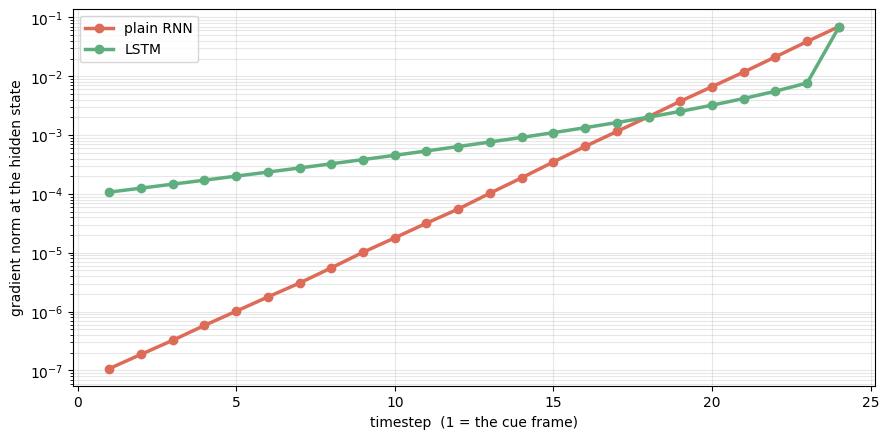

In [22]:
print(f"{'run':<14}{'final loss':>12}{'test acc':>11}")
for k in ["rnn-T4", "lstm-T4", "rnn-T24", "lstm-T24"]:
    h = seq_results[k]
    print(f"{k:<14}{h['train_loss'][-1]:>12.4f}{h['test_acc'][-1]*100:>10.2f}%")

torch.manual_seed(SEED)
gn_lstm = timestep_grad_norms(SeqModel("lstm"), 24)

plt.figure(figsize=(9, 4.5))
plt.semilogy(range(1, 25), gn_rnn, "o-", lw=2.5, color="#DE6B58", label="plain RNN")
plt.semilogy(range(1, 25), gn_lstm, "o-", lw=2.5, color="#5FAE7E", label="LSTM")
plt.xlabel("timestep  (1 = the cue frame)")
plt.ylabel("gradient norm at the hidden state")
plt.grid(alpha=.3, which="both"); plt.legend(); plt.tight_layout(); plt.show()


**Answer (3.4).** Both curves decay towards the cue — neither is flat. Report the decay factor for
each (the notebook prints one of them; compute the other the same way). Then answer the question
this part exists for:

The LSTM still multiplies `c_{t-1}` by the forget gate at every step. So it has not removed the
multiplication. Why does it not vanish anyway? Be specific about what the network can learn to do
with `f_t`, and why it could not do the same thing with `W_hh` in the plain RNN.

> _your answer here---     
the graph shows that the LSTM keeps much larger gradients at earlier timesteps compared to the plain RNN. at the first timestep, the RNN gradient is around \(10^{-7}\), while the LSTM is around \(10^{-4}\), which is about 1000 times larger.
this happens because the LSTM uses a cell state and gates to control what information to remember or forget. it helps the gradients flow backward through longer sequences and reduces the vanishing gradient problem, making it easier to learn information from the first frame

# Wrapping up — the part that is actually being assessed

You built two networks that failed and repaired both. The repairs look unrelated. They are not.

**Q1.** Write down, side by side, what the plain 26-layer CNN and the plain RNN at `T=24` have in
common. Your answer should mention what quantity is repeatedly multiplied in each case.

> _your answer here_   
both the plain CNN and RNN have a similar problem with gradient propagation. in the CNN and gradients are repeatedly multiplied by the derivatives of each layer as they travel backward through the network. in the RNN gradients are repeatedly multiplied by the recurrent weight matrix and activation derivatives across timesteps.    
these multiplications can make gradients become very small or very large which makes learning difficult in both cases.

**Q2.** A residual block computes `H(x) = F(x) + x`. An LSTM computes `c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t`.
Both are additions. Explain what the addition buys in each case, and name the coordinate — depth
or time — along which each one is defending a signal.

> _your answer here_   
both residual connections and LSTMs use addition to help information pass through the network.   
in the residual CNN the shortcut adds the original input to the output of the block. this gives gradients a more direct path through the networks depth.   
in the LSTM the cell state adds new information while keeping previous information using the forget gate. by learning to keep this gate close to 1, the LSTM can preserve information across time without losing most of its gradient.

**Q3.** You now have four measured numbers from Part 3 (`rnn/lstm` × `T=4/24`). Suppose a colleague
proposes replacing the LSTM with a 1D convolution over a fixed window of the last 8 frames.
On this specific task, would that work? Say what it would do to the `T=4` case and to the `T=24`
case, and why.

> _your answer here_   
using a 1D convolution over the last 8 frames could work for T=4 because all the frames including the first and last are available within the window.
but for T=24, it would not work properly because the first frame is outside the last 8 frames. since the task needs information from both the first and last frames, the model would only have incomplete information and its accuracy would likely stay around 10%, which is the chance level.

**Q4.** Look back at your Part 2 result. `depth26-res` beat `depth8-res` by only a little, and cost
far more compute. If this model had to run on a camera with a 25 ms budget per frame, which of your
four networks would you ship, and what would you measure before deciding?

> _your answer here_   
based on my results i would choose the depth8 res network because it reached 74.60% accuracy while depth8-plain reached 73.78%. the deeper residual network reached only 64.58 and took much longer to train.
before making the final decision I would measure the actual inference time per frame memory usage and power consumption on the camera hardware. Training time alone cannot tell us whether the model meets the 25 ms requirement.


---
### Submission checklist

- [ ] Every `assert` in the notebook passes
- [ ] Both plots in Part 2 (loss curves, block gradient norms) are present
- [ ] Both plots in Part 3 (timestep gradient norms, RNN vs LSTM) are present
- [ ] The results table in 2.2 and the one in 3.4 are filled in with your numbers
- [ ] All eight **Answer** boxes are written, in your own words
- [ ] The notebook runs top to bottom on a fresh runtime without editing anything

**Do not submit a notebook whose outputs were cleared.** The numbers are the evidence.
